# Agentic Self-Correction Evaluation — MBPP & HumanEval

Two-table evaluation of LABD / LABD+GRPO Qwen-3 models as **self-correcting agents**.

**What this notebook fixes / adds vs. the original:**

1. **Real tokenizer** — token counts now use the actual Qwen-3 tokenizer (`add_special_tokens=False`) on **assistant turns only**, instead of the `len(text)//4` heuristic.
2. **Both benchmarks** — handles the nested `{humaneval, mbpp}` file layout in one pass.
3. **Two evaluation tables per benchmark**
   * **Solved (lenient)** — functional correctness only.
   * **Solved + correct tool calling (strict)** — functional correctness **and** *every* assistant turn emits a well-formed `<execute> ... </execute>` block (full tag match via regex, not the bare word `execute`).
4. **Correct terminology** — `Pass@k` → **`Iter-k`** (feedback-conditioned iterative attempts, not independent samples).
5. **Richer metrics** — `Gain` (Iter-3 − Iter-1), `Correction Rate (CR)`, `Tok (1st)`, `Tok (All)`, `Token Overhead`, plus a **format-compliance gap** analysis.
6. **Better visualizations** — uplift, correction trajectories, lenient-vs-strict compliance gap, token overhead, cost/accuracy frontier, correction-rate scaling, and a Δ-over-base heatmap.

> **Note on iteration semantics.** `Iter-k` is the cumulative fraction of tasks solved *within* `k` feedback-driven attempts. A task solved at attempt 2 counts toward Iter-2 and Iter-3 but not Iter-1.


## 0. Setup

In [ ]:
import json, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

### 0.1 Tokenizer

We load the **Qwen-3 tokenizer** once. The tokenizer is shared across all Qwen-3 sizes
(0.6B–8B), so a single instance is sufficient and we avoid pulling multi-GB model weights
just to count tokens.

If you prefer the exact Unsloth call from your training script, the commented block does the
same thing — but note it downloads full weights, which is unnecessary for token counting.

In [ ]:
from transformers import AutoTokenizer

TOKENIZER_NAME = "moazeldegwy/Qwen3-0.6B-LABD-2.1-SFT"
FALLBACK_TOKENIZER = "Qwen/Qwen3-0.6B"

try:
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME, trust_remote_code=True)
    print(f"Loaded tokenizer: {TOKENIZER_NAME}")
except Exception as e:
    print(f"[WARN] could not load {TOKENIZER_NAME} ({e}); falling back to {FALLBACK_TOKENIZER}")
    tokenizer = AutoTokenizer.from_pretrained(FALLBACK_TOKENIZER, trust_remote_code=True)

config.json:   0%|          | 0.00/1.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/499 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/4.91k [00:00<?, ?B/s]

Loaded tokenizer: moazeldegwy/Qwen3-0.6B-LABD-2.1-SFT


## 1. Configuration

In [ ]:
# Directory containing the .jsonl evaluation logs
DATA_DIR = "."
MAX_ITERS = 3

# Per-model evaluation logs, split by benchmark
FILES = {
    "Qwen-0.6B (LABD)": {
        "humaneval": "humaneval_SFT_qwen3_0_6B_labd_2_1.jsonl",
        "mbpp":      "MBPP_SFT_qwen3_0_6B_labd_2_1.jsonl",
    },
    "Qwen-0.6B (LABD+GRPO)": {
        "humaneval": "humaneval_GRPO_qwen3_0_6B_labd_2_1.jsonl",
        "mbpp":      "MBPP_GRPO_qwen3_0_6B_labd_2_1.jsonl",
    },
    "Qwen-1.7B (LABD)": {
        "humaneval": "humaneval_SFT_qwen3_1_7B_labd_2.1.jsonl",
        "mbpp":      "MBPP_SFT_qwen3_1_7B_labd_2_1.jsonl",
    },
    "Qwen-1.7B (LABD+GRPO)": {
        "humaneval": "humaneval_GRPO_qwen3_1_7B_labd_2.1.jsonl",
        "mbpp":      "MBPP_GRPO_qwen3_1_7B_labd_2_1.jsonl",
    },
    "Qwen-4B (LABD)": {
        "humaneval": "humaneval_SFT_qwen3_4B_labd_2_1.jsonl",
        "mbpp":      "MBPP_SFT_qwen3_4B_labd_2_1.jsonl",
    },
    "Qwen-4B (LABD+GRPO)": {
        "humaneval": "humaneval_GRPO_qwen3_4B_labd_2_1.jsonl",
        "mbpp":      "MBPP_GRPO_qwen3_4B_labd_2_1.jsonl",
    },
    "Qwen-8B (LABD)": {
        "humaneval": "humaneval_SFT_qwen3_8B_labd_2_1.jsonl",
        "mbpp":      "MBPP_SFT_qwen3_8B_labd_2_1.jsonl",
    },
    "Qwen-8B (LABD+GRPO)": {
        "humaneval": "humaneval_GRPO_qwen3_8B_labd_2_1.jsonl",
        "mbpp":      "MBPP_GRPO_qwen3_8B_labd_2_1.jsonl",
    },
}

# Official base-model single-pass accuracy.
BASE_BENCHMARKS = {
    "mbpp": {
        "Qwen-0.6B": 36.60,
        "Qwen-1.7B": 55.40,
        "Qwen-4B":   67.00,
        "Qwen-8B":   69.80,
    },
    "humaneval": {
        "Qwen-0.6B": 34.2,
        "Qwen-1.7B": 54.5,
        "Qwen-4B":   71.0,
        "Qwen-8B":   87.2
    },
}

SIZE_ORDER = ["0.6B", "1.7B", "4B", "8B"]

## 2. Parsing & metric helpers

**Tool-calling detection (strict).** A turn is a valid tool call only if it contains a complete
`<execute> ... </execute>` block. We match the full tag pair with a non-greedy DOTALL regex, so
a stray mention of the word *execute*, a markdown ```python fence, or raw code does **not** count.

A task is *solved with correct tool calling* iff it is functionally solved **and** every assistant
turn in its trajectory is a valid `<execute>` call.

In [ ]:
EXECUTE_RE = re.compile(r"<execute>.*?</execute>", re.DOTALL | re.IGNORECASE)
FENCE_RE   = re.compile(r"```")
CODEY_RE   = re.compile(r"\b(def|class|import|return|for|while|lambda)\b")

def turn_format(content: str) -> str:
    '''Classify a single assistant turn's output format.'''
    if not content:
        return "text_only"
    if EXECUTE_RE.search(content):
        return "execute"
    if FENCE_RE.search(content):
        return "code_fence"
    if CODEY_RE.search(content):
        return "raw_code"
    return "text_only"

def count_tokens(text: str) -> int:
    if not text:
        return 0
    return len(tokenizer.encode(text, add_special_tokens=False))

def analyze_record(record: dict) -> dict:
    '''Per-task analysis: correctness, tool-call compliance, and generated-token counts.'''
    solved = bool(record.get("solved", False))
    conv = record.get("conversation", []) or []

    # Generated text = assistant turns only
    assistant_turns = [m.get("content", "") for m in conv if m.get("role") == "assistant"]
    formats = [turn_format(c) for c in assistant_turns]

    # Strict format gate: at least one turn AND every turn is a valid <execute> call
    all_turns_execute = len(formats) > 0 and all(f == "execute" for f in formats)

    # attempts_used = the attempt index at which the task resolved.
    attempts = record.get("attempts_used", None)
    if not attempts or attempts <= 0:
        attempts = max(len(assistant_turns), 1)

    # Generated-token cost (assistant turns only)
    tok_first = count_tokens(assistant_turns[0]) if assistant_turns else 0
    tok_all   = sum(count_tokens(c) for c in assistant_turns)

    return {
        "solved": solved,
        "solved_strict": solved and all_turns_execute,
        "all_turns_execute": all_turns_execute,
        "attempts_used": int(attempts),
        "n_turns": len(assistant_turns),
        "tok_first": tok_first,
        "tok_all": tok_all,
        "formats": formats,
    }

In [ ]:
def _cumulative(df: pd.DataFrame, solved_col: str, max_iters: int) -> dict:
    '''Cumulative count of tasks solved within k attempts, for k = 1..max_iters.'''
    total = len(df)
    return {
        k: int((df[solved_col] & (df["attempts_used"] <= k)).sum())
        for k in range(1, max_iters + 1)
    }

def _pack_iters(counts: dict, total: int, max_iters: int, prefix: str) -> dict:
    out = {f"{prefix}Iter{k}": counts[k] / total * 100 for k in range(1, max_iters + 1)}
    i1, i3 = out[f"{prefix}Iter1"], out[f"{prefix}Iter{max_iters}"]
    out[f"{prefix}Gain"] = i3 - i1                                   # internal recovery gain
    out[f"{prefix}CR"]   = (i3 - i1) / (100 - i1) * 100 if i1 < 100 else 0.0  # Correction Rate
    return out

def calculate_file_metrics(file_path: str, max_iters: int = MAX_ITERS):
    if not os.path.exists(file_path):
        print(f"  [WARN] missing: {file_path}")
        return None

    recs = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                recs.append(analyze_record(json.loads(line)))
            except json.JSONDecodeError:
                continue
    if not recs:
        return None

    df = pd.DataFrame(recs)
    total = len(df)

    out = {}
    out.update(_pack_iters(_cumulative(df, "solved",        max_iters), total, max_iters, "L_"))
    out.update(_pack_iters(_cumulative(df, "solved_strict", max_iters), total, max_iters, "S_"))

    tok_first = float(df["tok_first"].mean())
    tok_all   = float(df["tok_all"].mean())
    all_turn_formats = [f for fs in df["formats"] for f in fs]

    out.update({
        "Total":          total,
        "Solved_Lenient": int(df["solved"].sum()),
        "Solved_Strict":  int(df["solved_strict"].sum()),
        "Format_Gap":     int(df["solved"].sum() - df["solved_strict"].sum()),
        "Tok_1st":        tok_first,
        "Tok_All":        tok_all,
        "Overhead":       (tok_all / tok_first) if tok_first > 0 else float("nan"),
        "Pct_Execute":    (np.mean([f == "execute" for f in all_turn_formats]) * 100
                           if all_turn_formats else 0.0),
    })
    return out

## 3. Process all files

In [ ]:
def parse_model_name(name: str):
    size = name.split("(")[0].replace("Qwen-", "").strip()
    method = name.split("(")[1].rstrip(") ").strip() if "(" in name else ""
    return size, method

rows = []
print("Processing models...")
for model_name, paths in FILES.items():
    size, method = parse_model_name(model_name)
    for bench, fname in paths.items():
        fp = os.path.join(DATA_DIR, fname)
        m = calculate_file_metrics(fp)
        if m is None:
            continue
        m.update({
            "Model": model_name,
            "Size": size,
            "Method": method,
            "Benchmark": bench,
            "Base": BASE_BENCHMARKS.get(bench, {}).get(f"Qwen-{size}"),
        })
        rows.append(m)
        print(f"  -> {model_name:24s} [{bench:9s}]  "
              f"lenient Iter-3={m['L_Iter3']:.1f}%  strict Iter-3={m['S_Iter3']:.1f}%  "
              f"gap={m['Format_Gap']} tasks")

DF = pd.DataFrame(rows)
if not DF.empty:
    DF["Size"] = pd.Categorical(DF["Size"], categories=SIZE_ORDER, ordered=True)
    DF = DF.sort_values(["Benchmark", "Size", "Method"]).reset_index(drop=True)
print(f"\nLoaded {len(DF)} (model x benchmark) result rows.")

Processing models...
  -> Qwen-0.6B (LABD)         [humaneval]  lenient Iter-3=50.6%  strict Iter-3=50.6%  gap=0 tasks
  -> Qwen-0.6B (LABD)         [mbpp     ]  lenient Iter-3=46.8%  strict Iter-3=46.4%  gap=2 tasks
  -> Qwen-0.6B (LABD+GRPO)    [humaneval]  lenient Iter-3=48.2%  strict Iter-3=47.0%  gap=2 tasks
  -> Qwen-0.6B (LABD+GRPO)    [mbpp     ]  lenient Iter-3=48.2%  strict Iter-3=48.0%  gap=1 tasks
  -> Qwen-1.7B (LABD)         [humaneval]  lenient Iter-3=79.3%  strict Iter-3=74.4%  gap=8 tasks
  -> Qwen-1.7B (LABD)         [mbpp     ]  lenient Iter-3=67.4%  strict Iter-3=64.6%  gap=14 tasks
  -> Qwen-1.7B (LABD+GRPO)    [humaneval]  lenient Iter-3=84.1%  strict Iter-3=79.9%  gap=7 tasks
  -> Qwen-1.7B (LABD+GRPO)    [mbpp     ]  lenient Iter-3=67.6%  strict Iter-3=65.6%  gap=10 tasks
  -> Qwen-4B (LABD)           [humaneval]  lenient Iter-3=95.7%  strict Iter-3=92.1%  gap=6 tasks
  -> Qwen-4B (LABD)           [mbpp     ]  lenient Iter-3=87.0%  strict Iter-3=84.0%  gap=15 ta

## 4. Results tables

Two tables per benchmark:

* **Table A — Solved (lenient):** functional correctness only.
* **Table B — Solved + correct tool calling (strict):** correctness **and** all assistant turns use `<execute>`.

Columns: `Iter-1/2/3`, `Gain` (Iter-3 − Iter-1), `CR` (Correction Rate), `Tok (1st)`,
`Tok (All)`, `Overhead`. `Base` is the official single-pass accuracy (`--` for HumanEval).

In [ ]:
def fmt_base(v):
    return "--" if (v is None or (isinstance(v, float) and np.isnan(v))) else f"{v:.2f}"

def build_table(df: pd.DataFrame, bench: str, mode: str) -> pd.DataFrame:
    p = "L_" if mode == "lenient" else "S_"
    sub = df[df["Benchmark"] == bench].copy()
    colmap = {
        "Model": "Model", "Base": "Base",
        f"{p}Iter1": "Iter-1", f"{p}Iter2": "Iter-2", f"{p}Iter3": "Iter-3",
        f"{p}Gain": "Gain", f"{p}CR": "CR (%)",
        "Tok_1st": "Tok (1st)", "Tok_All": "Tok (All)", "Overhead": "Overhead",
    }
    t = sub[list(colmap)].rename(columns=colmap)
    t["Base"] = sub["Base"].map(fmt_base).values
    num = ["Iter-1", "Iter-2", "Iter-3", "Gain", "CR (%)", "Tok (1st)", "Tok (All)", "Overhead"]
    t[num] = t[num].round(2)
    return t.reset_index(drop=True)

def show(title, table):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(table.to_string(index=False))

for bench, label in [("mbpp", "MBPP"), ("humaneval", "HumanEval")]:
    show(f"TABLE A — {label}: Solved (lenient, functional correctness only)",
         build_table(DF, bench, "lenient"))
    show(f"TABLE B — {label}: Solved + correct tool calling (strict <execute> compliance)",
         build_table(DF, bench, "strict"))


TABLE A — MBPP: Solved (lenient, functional correctness only)
                Model  Base  Iter-1  Iter-2  Iter-3  Gain  CR (%)  Tok (1st)  Tok (All)  Overhead
     Qwen-0.6B (LABD) 36.60    38.2    45.6    46.8   8.6   13.92    1719.72    2199.15      1.28
Qwen-0.6B (LABD+GRPO) 36.60    38.0    45.6    48.2  10.2   16.45    1690.20    2134.07      1.26
     Qwen-1.7B (LABD) 55.40    60.6    65.0    67.4   6.8   17.26    2368.34    3068.36      1.30
Qwen-1.7B (LABD+GRPO) 55.40    62.4    66.0    67.6   5.2   13.83    2371.66    3091.12      1.30
       Qwen-4B (LABD) 67.00    80.8    85.4    87.0   6.2   32.29    2011.50    2518.37      1.25
  Qwen-4B (LABD+GRPO) 67.00    81.4    85.0    86.6   5.2   27.96    1947.13    2429.04      1.25
       Qwen-8B (LABD) 69.80    83.8    86.4    87.8   4.0   24.69    1918.93    2324.83      1.21
  Qwen-8B (LABD+GRPO) 69.80    84.0    88.2    90.2   6.2   38.75    1985.58    2360.72      1.19

TABLE B — MBPP: Solved + correct tool calling (strict 

### 4.1 Format-compliance gap (lenient vs. strict)

In [ ]:
gap = DF[["Model", "Benchmark", "Total", "Solved_Lenient", "Solved_Strict",
          "Format_Gap", "Pct_Execute"]].copy()
gap["Lenient (%)"]   = (gap["Solved_Lenient"] / gap["Total"] * 100).round(2)
gap["Strict (%)"]    = (gap["Solved_Strict"]  / gap["Total"] * 100).round(2)
gap["Gap (pp)"]      = (gap["Lenient (%)"] - gap["Strict (%)"]).round(2)
gap["Pct_Execute"]   = gap["Pct_Execute"].round(2)
gap = gap.rename(columns={"Format_Gap": "Gap (tasks)", "Pct_Execute": "Turns w/ <execute> (%)"})

show("FORMAT-COMPLIANCE GAP — correct code that broke the <execute> tool-calling format",
     gap[["Model", "Benchmark", "Total", "Solved_Lenient", "Solved_Strict",
          "Gap (tasks)", "Lenient (%)", "Strict (%)", "Gap (pp)", "Turns w/ <execute> (%)"]])

# Persist master table + per-table CSVs
DF.to_csv("results_master.csv", index=False)
for bench, label in [("mbpp", "MBPP"), ("humaneval", "HumanEval")]:
    build_table(DF, bench, "lenient").to_csv(f"table_{label}_lenient.csv", index=False)
    build_table(DF, bench, "strict").to_csv(f"table_{label}_strict.csv", index=False)
print("\nSaved: results_master.csv + table_{MBPP,HumanEval}_{lenient,strict}.csv")


FORMAT-COMPLIANCE GAP — correct code that broke the <execute> tool-calling format
                Model Benchmark  Total  Solved_Lenient  Solved_Strict  Gap (tasks)  Lenient (%)  Strict (%)  Gap (pp)  Turns w/ <execute> (%)
     Qwen-0.6B (LABD) humaneval    164              83             83            0        50.61       50.61      0.00                   91.62
Qwen-0.6B (LABD+GRPO) humaneval    164              79             77            2        48.17       46.95      1.22                   90.62
     Qwen-1.7B (LABD) humaneval    164             130            122            8        79.27       74.39      4.88                   79.92
Qwen-1.7B (LABD+GRPO) humaneval    164             138            131            7        84.15       79.88      4.27                   82.26
       Qwen-4B (LABD) humaneval    164             157            151            6        95.73       92.07      3.66                   88.38
  Qwen-4B (LABD+GRPO) humaneval    164             158           

## 5. Visualizations

Each plot uses the **lenient** metric unless stated otherwise. Figures are saved as PNG.

### 5.1 Performance uplift — Base vs. Iter-1 vs. Iter-3

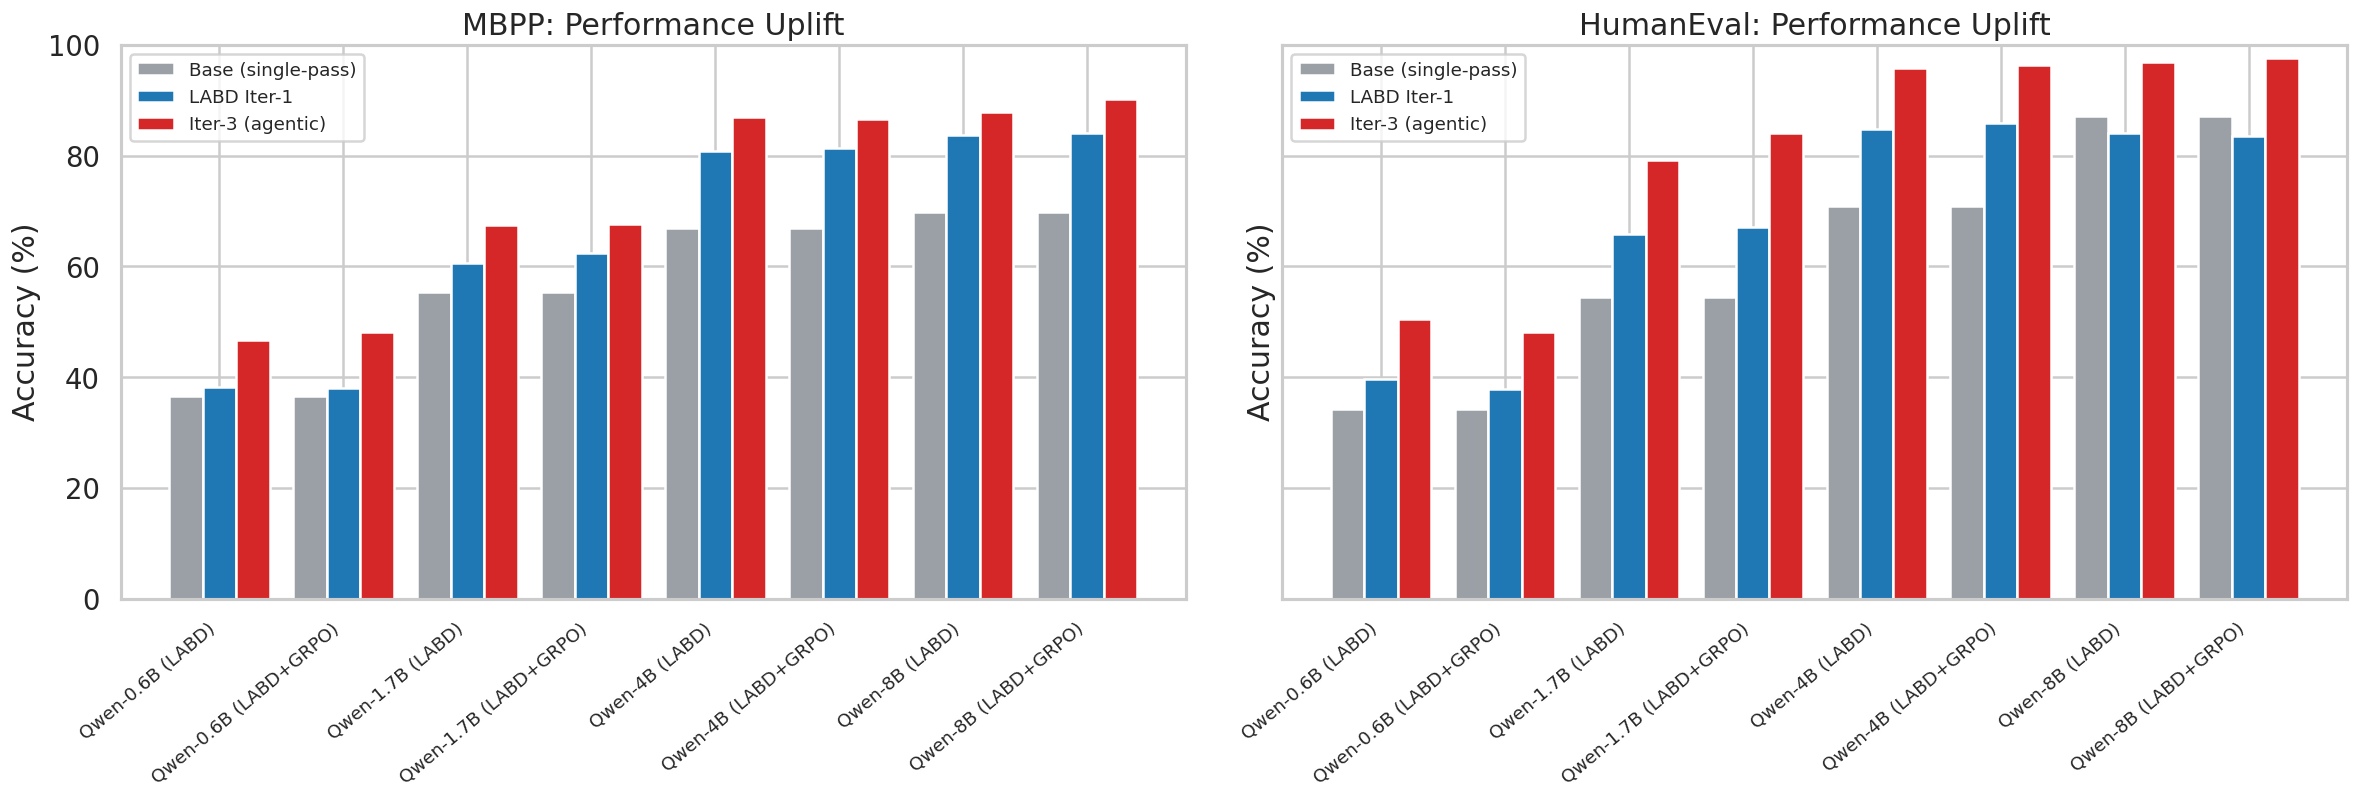

In [ ]:
def order_models(df_b):
    return df_b.sort_values(["Size", "Method"])

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
for ax, (bench, label) in zip(axes, [("mbpp", "MBPP"), ("humaneval", "HumanEval")]):
    d = order_models(DF[DF["Benchmark"] == bench])
    x = np.arange(len(d)); w = 0.27
    base = d["Base"].astype(float).values  # NaN for HumanEval -> bars skipped
    ax.bar(x - w, base,        w, label="Base (single-pass)", color="#9aa0a6")
    ax.bar(x,     d["L_Iter1"], w, label="LABD Iter-1",       color="#1f77b4")
    ax.bar(x + w, d["L_Iter3"], w, label="Iter-3 (agentic)",  color="#d62728")
    ax.set_title(f"{label}: Performance Uplift")
    ax.set_xticks(x); ax.set_xticklabels(d["Model"], rotation=40, ha="right", fontsize=11)
    ax.set_ylim(0, 100); ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig("fig1_uplift.eps", bbox_inches="tight"); plt.show()

### 5.2 Self-correction trajectories (Iter-1 → Iter-3)

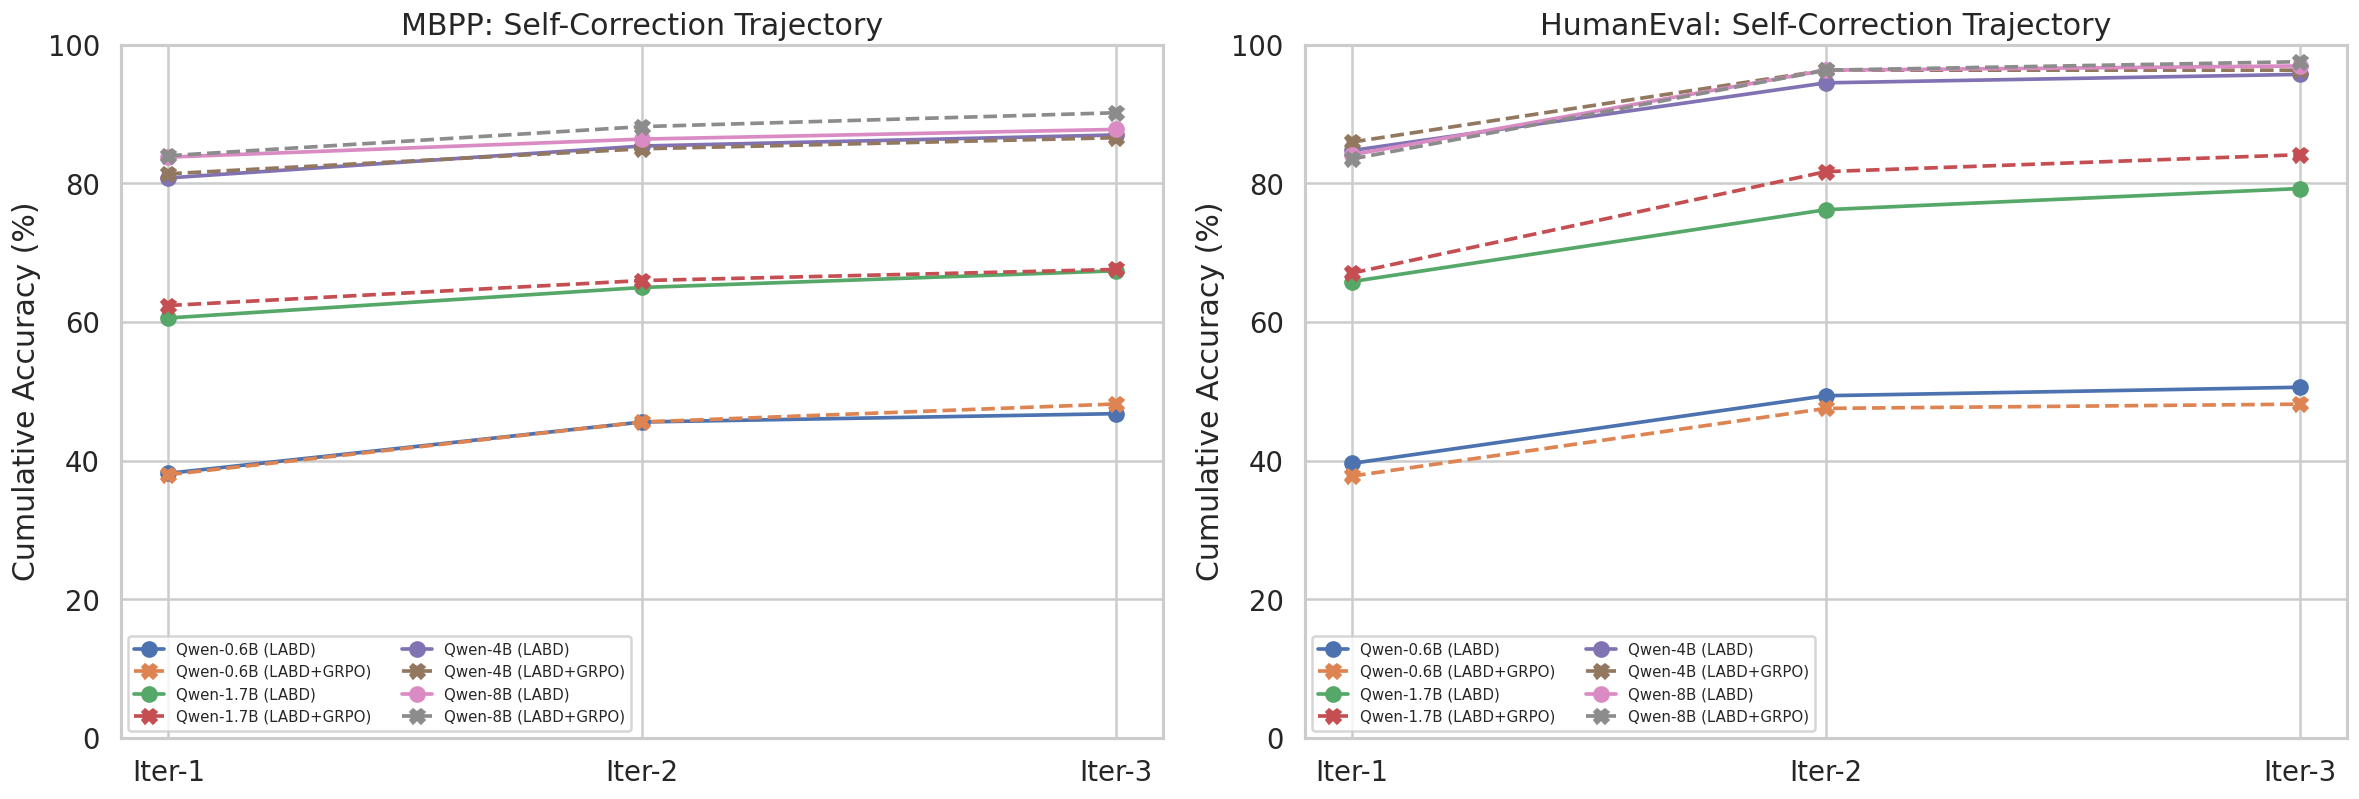

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
for ax, (bench, label) in zip(axes, [("mbpp", "MBPP"), ("humaneval", "HumanEval")]):
    d = order_models(DF[DF["Benchmark"] == bench])
    for _, r in d.iterrows():
        ls = "--" if "GRPO" in r["Method"] else "-"
        mk = "X" if "GRPO" in r["Method"] else "o"
        ax.plot(["Iter-1", "Iter-2", "Iter-3"],
                [r["L_Iter1"], r["L_Iter2"], r["L_Iter3"]],
                marker=mk, linestyle=ls, linewidth=2.2, markersize=9, label=r["Model"])
    ax.set_title(f"{label}: Self-Correction Trajectory")
    ax.set_ylabel("Cumulative Accuracy (%)"); ax.set_ylim(0, 100)
    ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); plt.savefig("fig2_trajectory.eps", bbox_inches="tight"); plt.show()

### 5.3 Tool-calling compliance gap (lenient vs. strict)

The most directly diagnostic plot for the two-table question: how much accuracy is *real but
non-compliant* — correct code that abandoned the `<execute>` format. The red segment is accuracy
lost under strict evaluation.

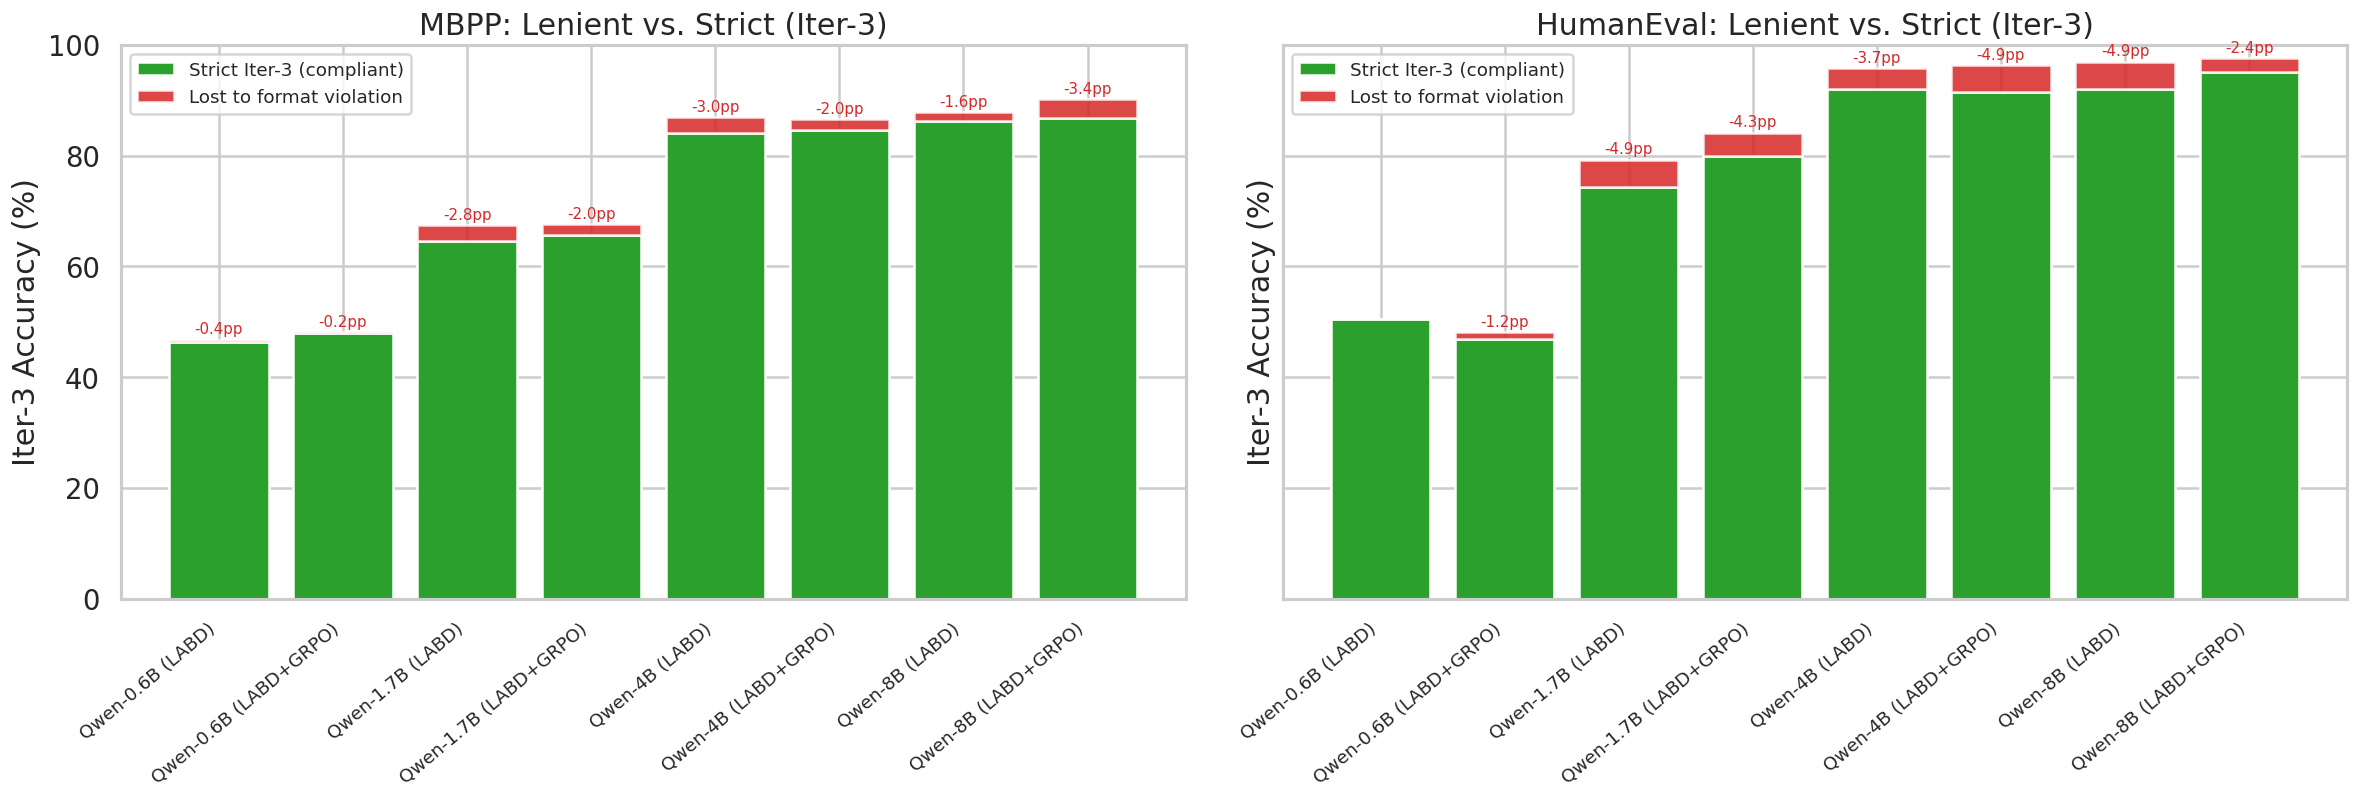

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
for ax, (bench, label) in zip(axes, [("mbpp", "MBPP"), ("humaneval", "HumanEval")]):
    d = order_models(DF[DF["Benchmark"] == bench])
    x = np.arange(len(d))
    strict = d["S_Iter3"].values
    lenient = d["L_Iter3"].values
    ax.bar(x, strict, color="#2ca02c", label="Strict Iter-3 (compliant)")
    ax.bar(x, lenient - strict, bottom=strict, color="#d62728", alpha=0.85,
           label="Lost to format violation")
    for xi, (le, st) in enumerate(zip(lenient, strict)):
        if le - st > 0.05:
            ax.text(xi, le + 1, f"-{le-st:.1f}pp", ha="center", fontsize=9, color="#d62728")
    ax.set_title(f"{label}: Lenient vs. Strict (Iter-3)")
    ax.set_xticks(x); ax.set_xticklabels(d["Model"], rotation=40, ha="right", fontsize=11)
    ax.set_ylim(0, 100); ax.set_ylabel("Iter-3 Accuracy (%)"); ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig("fig3_compliance_gap.eps", bbox_inches="tight"); plt.show()

### 5.4 Token cost — single turn vs. full agentic loop

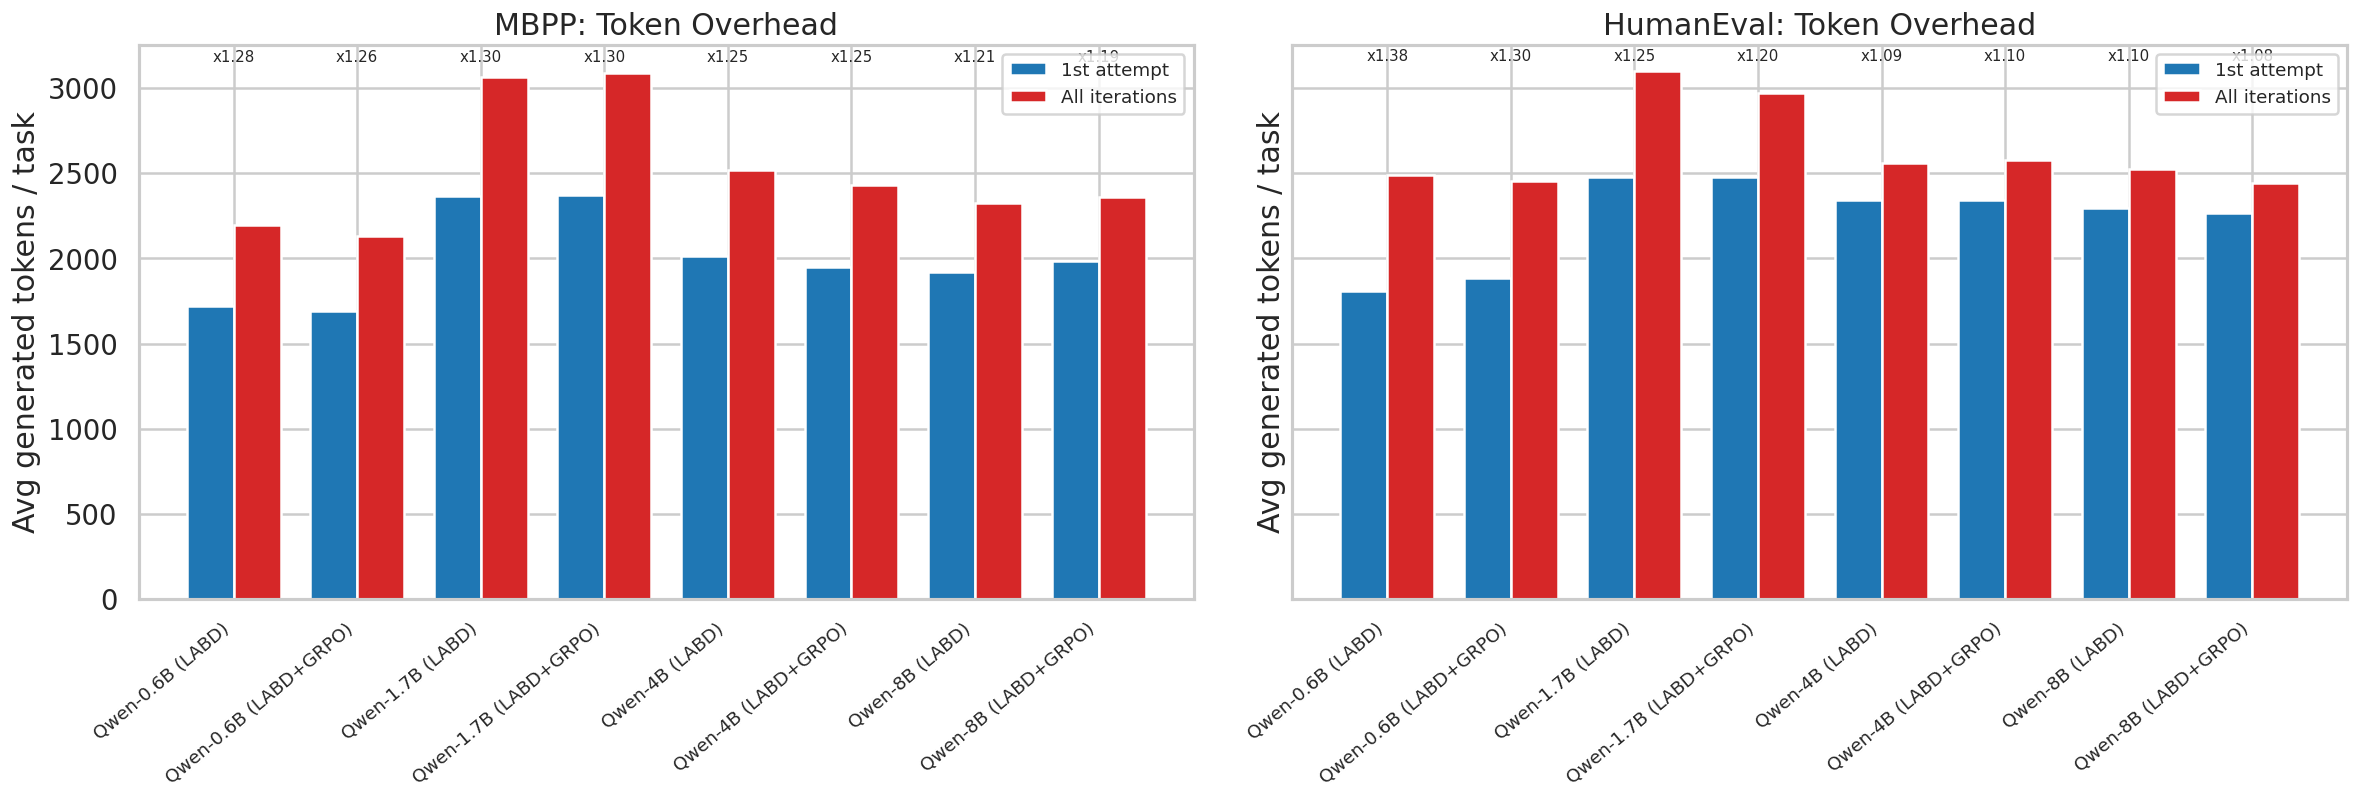

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
for ax, (bench, label) in zip(axes, [("mbpp", "MBPP"), ("humaneval", "HumanEval")]):
    d = order_models(DF[DF["Benchmark"] == bench])
    x = np.arange(len(d)); w = 0.38
    ax.bar(x - w/2, d["Tok_1st"], w, label="1st attempt", color="#1f77b4")
    ax.bar(x + w/2, d["Tok_All"], w, label="All iterations", color="#d62728")
    for xi, ov in zip(x, d["Overhead"]):
        ax.text(xi, d["Tok_All"].max() * 1.02, f"x{ov:.2f}", ha="center", fontsize=9)
    ax.set_title(f"{label}: Token Overhead")
    ax.set_xticks(x); ax.set_xticklabels(d["Model"], rotation=40, ha="right", fontsize=11)
    ax.set_ylabel("Avg generated tokens / task"); ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig("fig4_token_overhead.eps", bbox_inches="tight"); plt.show()

### 5.5 Cost vs. accuracy frontier

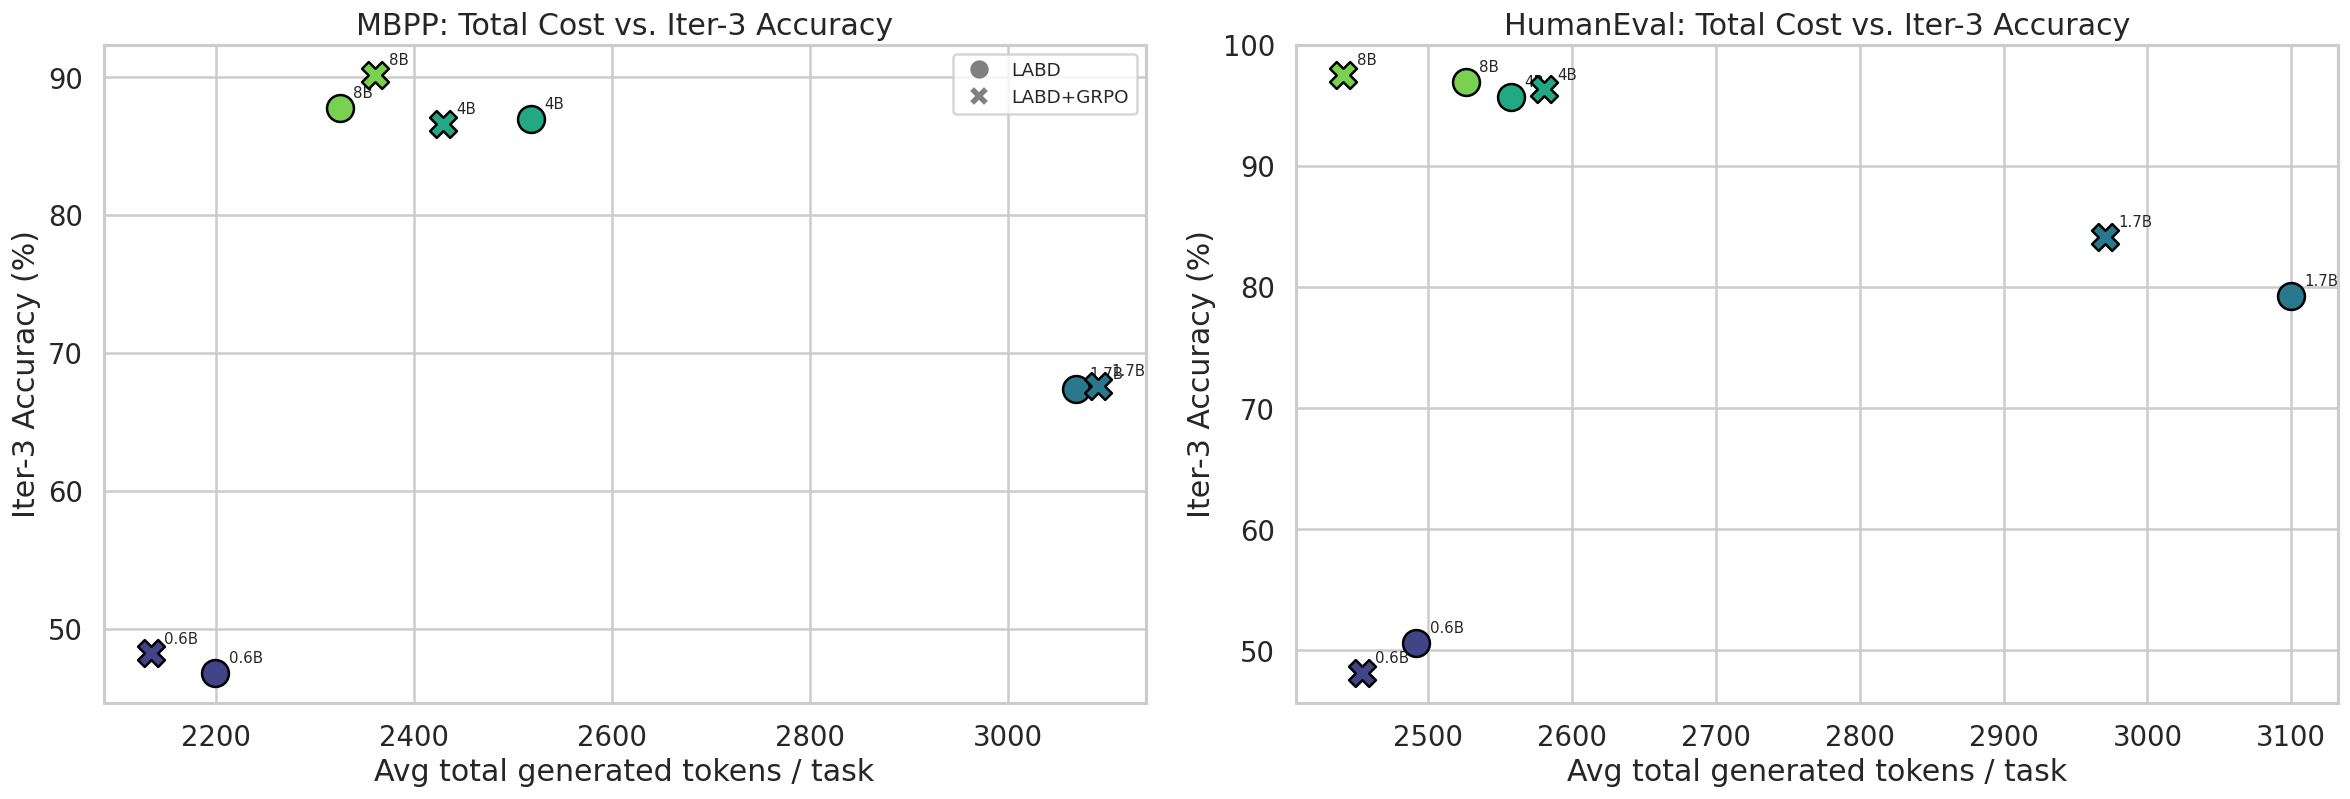

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
palette = dict(zip(SIZE_ORDER, sns.color_palette("viridis", len(SIZE_ORDER))))
for ax, (bench, label) in zip(axes, [("mbpp", "MBPP"), ("humaneval", "HumanEval")]):
    d = DF[DF["Benchmark"] == bench]
    for _, r in d.iterrows():
        mk = "X" if "GRPO" in r["Method"] else "o"
        ax.scatter(r["Tok_All"], r["L_Iter3"], s=260, marker=mk,
                   color=palette[str(r["Size"])], edgecolor="black", zorder=3)
        ax.annotate(f"{r['Size']}", (r["Tok_All"], r["L_Iter3"]),
                    textcoords="offset points", xytext=(8, 6), fontsize=9)
    ax.set_title(f"{label}: Total Cost vs. Iter-3 Accuracy")
    ax.set_xlabel("Avg total generated tokens / task"); ax.set_ylabel("Iter-3 Accuracy (%)")
from matplotlib.lines import Line2D
legend = [Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=12, label='LABD'),
          Line2D([0],[0], marker='X', color='w', markerfacecolor='gray', markersize=12, label='LABD+GRPO')]
axes[0].legend(handles=legend, fontsize=11)
plt.tight_layout(); plt.savefig("fig5_cost_accuracy.png", bbox_inches="tight"); plt.show()

### 5.6 Correction Rate by model size

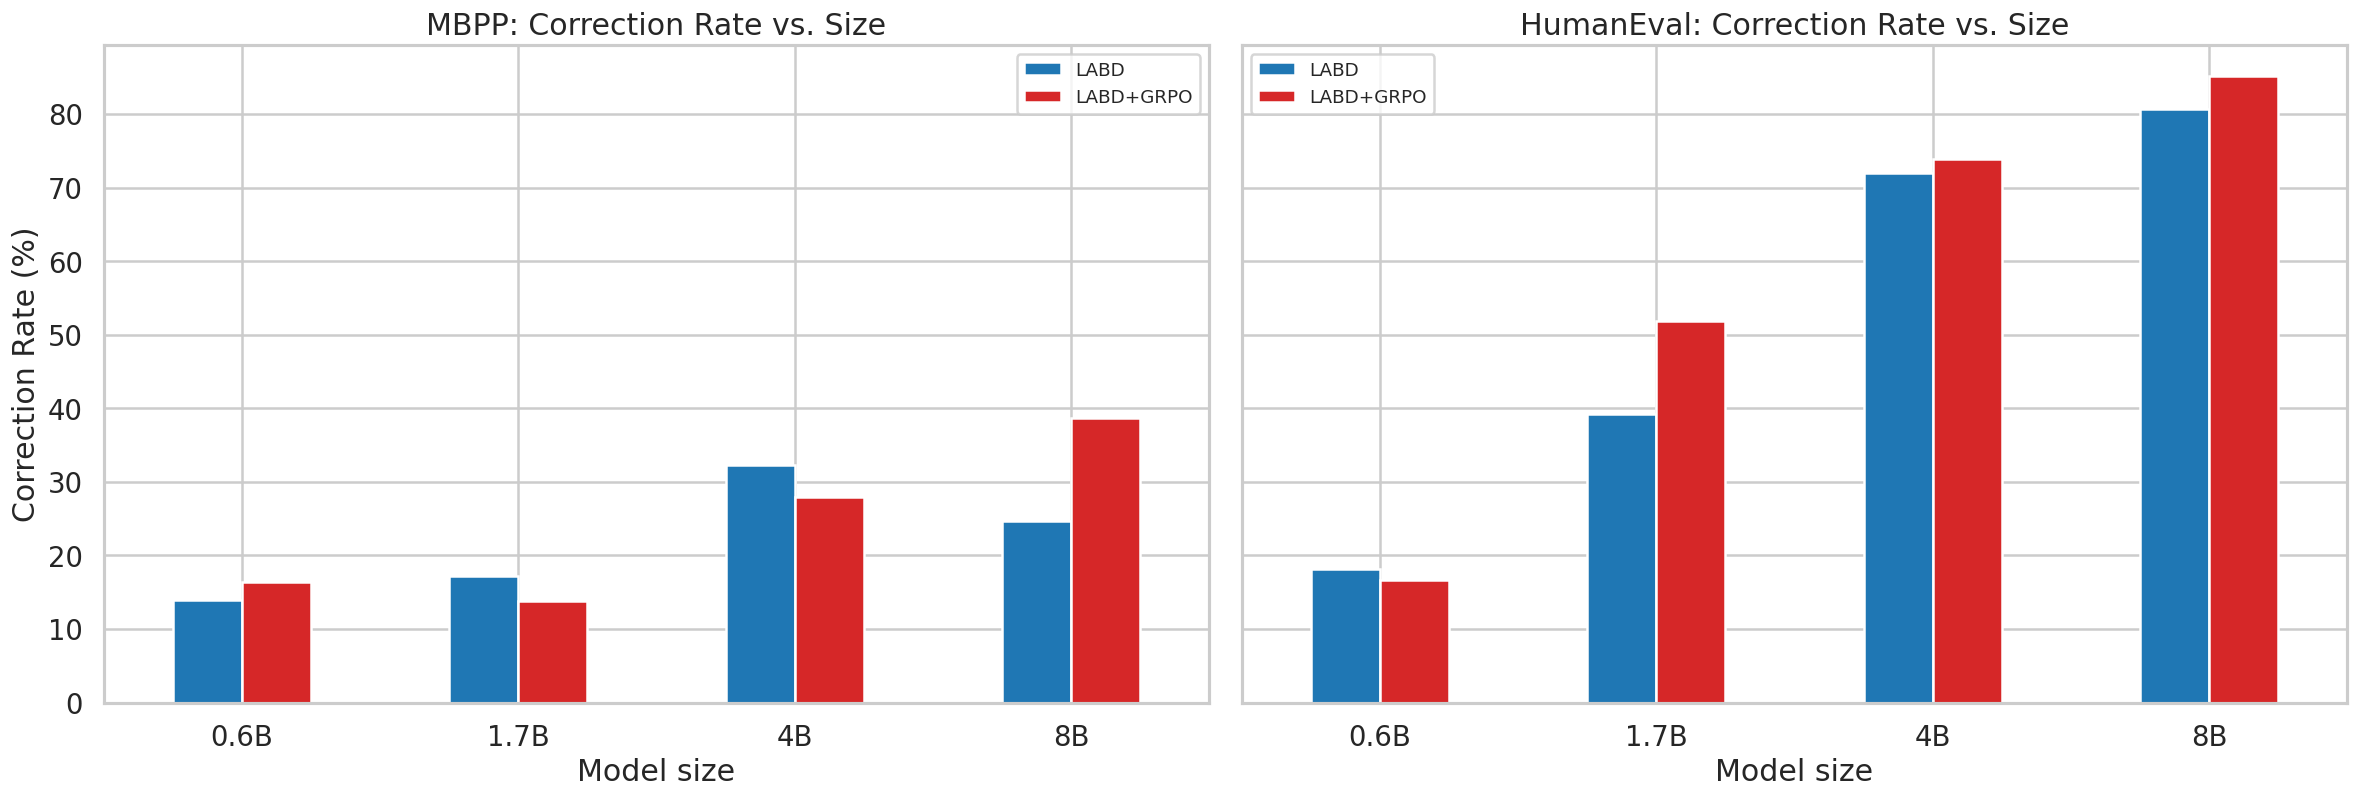

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
for ax, (bench, label) in zip(axes, [("mbpp", "MBPP"), ("humaneval", "HumanEval")]):
    d = DF[DF["Benchmark"] == bench]
    piv = d.pivot_table(index="Size", columns="Method", values="L_CR", observed=True)
    piv = piv.reindex(SIZE_ORDER)
    piv.plot(kind="bar", ax=ax, color=["#1f77b4", "#d62728"])
    ax.set_title(f"{label}: Correction Rate vs. Size")
    ax.set_ylabel("Correction Rate (%)"); ax.set_xlabel("Model size")
    ax.tick_params(axis="x", rotation=0); ax.legend(title="", fontsize=11)
plt.tight_layout(); plt.savefig("fig6_correction_rate.eps", bbox_inches="tight"); plt.show()

### 5.7 Δ over base (Iter-3 − Base) — MBPP only

HumanEval has no official base, so this capacity-threshold heatmap is shown for MBPP.

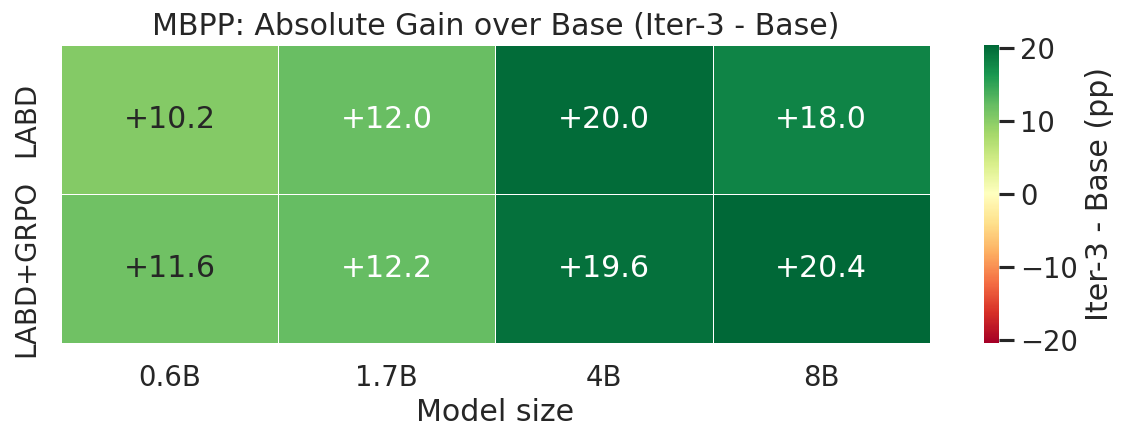

In [ ]:
d = DF[(DF["Benchmark"] == "mbpp") & DF["Base"].notna()].copy()
d["Delta"] = d["L_Iter3"] - d["Base"].astype(float)
piv = d.pivot_table(index="Method", columns="Size", values="Delta", observed=True)
piv = piv.reindex(columns=SIZE_ORDER)

plt.figure(figsize=(10, 4))
vmax = np.nanmax(np.abs(piv.values))
sns.heatmap(piv, annot=True, fmt="+.1f", cmap="RdYlGn", center=0,
            vmin=-vmax, vmax=vmax, linewidths=0.5, cbar_kws={"label": "Iter-3 - Base (pp)"})
plt.title("MBPP: Absolute Gain over Base (Iter-3 - Base)")
plt.ylabel(""); plt.xlabel("Model size")
plt.tight_layout(); plt.savefig("fig7_delta_heatmap.eps", bbox_inches="tight"); plt.show()

## 6. Notes on methodology

* **Tokens** are *generated* tokens only (assistant turns), encoded with the Qwen-3 tokenizer
  and `add_special_tokens=False`. `Tok (1st)` is the first attempt; `Tok (All)` is the full loop;
  `Overhead = Tok(All) / Tok(1st)`.
* **Iter-k** is cumulative and feedback-conditioned — distinct from independent-sample `Pass@k`.
* **Strict tool calling** requires a complete `<execute> ... </execute>` block in *every* assistant
  turn; markdown fences, raw code, or the bare word *execute* do not qualify.
* **Correction Rate** `CR = (Iter-3 − Iter-1) / (1 − Iter-1)` — recovery among initially failed tasks.
